In [1]:
max_long = "4"
max_short = "1"
period = "21"
stop_long = "0.5"
stop_short = "0.05"
hard_stop_long = "1"
hard_stop_short = "1"
leverage = "2"
# mom1m, mom2m, mom3m, mom6m, mom12m, mom12-1m-a, mom12-1m-b
signal = "mom12-1m-a"
gate = "mom12m-andor-6m"
variant_name = "default"
daily_exit = "False"
show_figs = "True"
use_live_data = "True"

Params: L=4 S=1 P=21 SL=0.5 SS=0.05 HL=1.0 HS=1.0 Lev=2.0 Sig=mom12-1m-a DX=False


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:00<00:00, 851.00it/s]


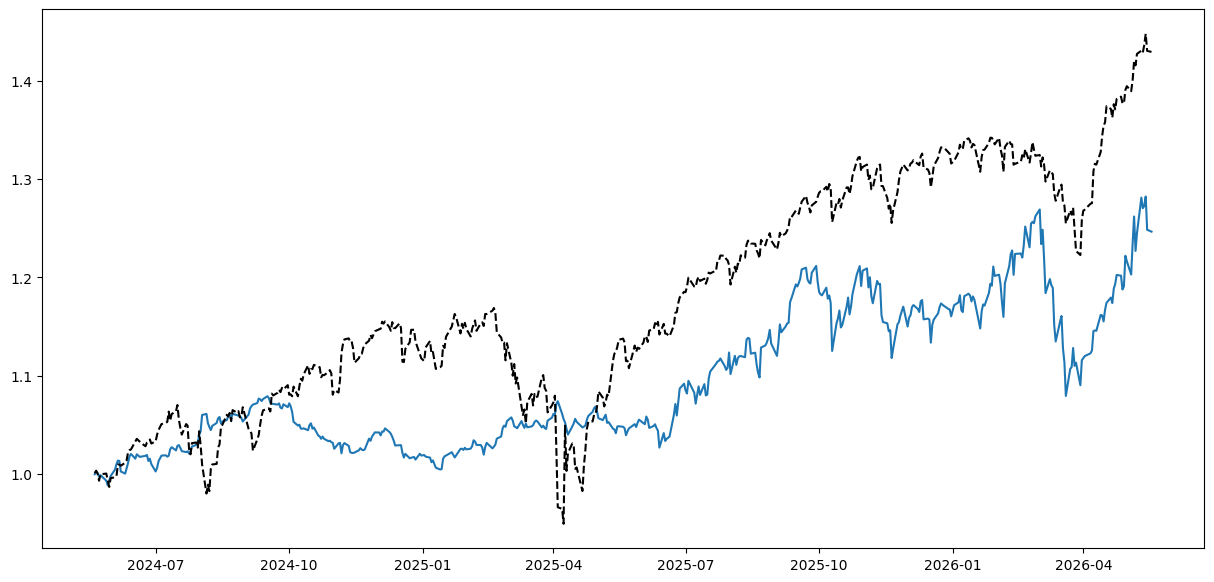

MTD PnL: 2.01%, MTD CAGR: 51.73%
SUMMARY: CAGR=11.74% (19.65%), MDD=-14.93% (-18.76%), Sharpe=0.85, Sortino=1.08 (1.49), IR=-0.41, WinRate=56.25%, Kelly=6.03, Half-Kelly=3.02


/var/folders/tl/9yq9dyyj1sl6tn4r875nj5ym0000gn/T/ipykernel_98004/2269542038.py:537: RuntimeWarning: invalid value encountered in scalar divide
  ir = ((rets - spy_rets).mean() * 252) / ((rets - spy_rets).std() * np.sqrt(252))


In [2]:
import polars as pl
import numpy as np
import pandas as pd
from typing import Callable, Literal
from tqdm import tqdm
import matplotlib.pyplot as plt
import scrapbook as sb

max_long_param = int(max_long)
max_short_param = int(max_short)
period_param = int(period)
stop_long_param = float(stop_long)
stop_short_param = float(stop_short)
hard_stop_long_param = float(hard_stop_long)
hard_stop_short_param = float(hard_stop_short)
leverage_param = float(leverage)
daily_exit_param = daily_exit.lower() == "true"
show_figs_param = show_figs.lower() == "true"
use_live_data_param = use_live_data.lower() == "true"

print(
    f"Params: L={max_long_param} S={max_short_param} P={period_param} SL={stop_long_param} SS={stop_short_param} HL={hard_stop_long_param} HS={hard_stop_short_param} Lev={leverage_param} Sig={signal} DX={daily_exit_param}"
)

sector_etfs = [
    "XLB",
    "XLC",
    "XLE",
    "XLF",
    "XLI",
    "XLK",
    "XLP",
    "XLRE",
    "XLU",
    "XLV",
    "XLY",
]
lev_2x = {
    "XLB": "UYM",
    "XLC": "XLC",
    "XLE": "DIG",
    "XLF": "UYG",
    "XLI": "UXI",
    "XLK": "ROM",
    "XLP": "UGE",
    "XLRE": "URE",
    "XLU": "UPW",
    "XLV": "RXL",
    "XLY": "UCC",
}
lev_3x = {
    "XLB": "UYM",
    "XLC": "XLC",
    "XLE": "ERX",
    "XLF": "FAS",
    "XLI": "DUSL",
    "XLK": "TECL",
    "XLP": "UGE",
    "XLRE": "DRN",
    "XLU": "UTSL",
    "XLV": "CURE",
    "XLY": "WANT",
}

etf_mapping = {}
if variant_name == "2x":
    etf_mapping = lev_2x
elif variant_name == "3x":
    etf_mapping = lev_3x

yz_k, yz_win = 0.34, 25

signals_map = {
    "mom12m": pl.col("mom12m"),
    "mom1m": pl.col("mom1m"),
    "mom2m": pl.col("mom2m"),
    "mom3m": pl.col("mom3m"),
    "mom6m": pl.col("mom6m"),
    "mom12-1m-a": pl.col("mom12m") - pl.col("mom1m"),
    "mom12-1m-b": pl.col("mom11m").shift(21).over("symbol"),
}
signal_expr = signals_map[signal]

gates_map = {
    "mom12m-andor-6m": [
        (pl.col("mom12m") > 0) | (pl.col("mom6m") > 0),
        (pl.col("mom12m") < 0) & (pl.col("mom6m") < 0),
    ],
    "ema50d": [
        pl.col("ema50d") < pl.col("close"),
        pl.col("ema50d") > pl.col("close"),
    ],
}
gate_expr = gates_map[gate]

if use_live_data_param:
    from yf import yf_download
    from tempfile import NamedTemporaryFile

    with NamedTemporaryFile() as f:
        yf_download(
            [
                "SPY",
                "XLC",
                "XLE",
                "XLF",
                "XLI",
                "XLK",
                "XLP",
                "XLRE",
                "XLU",
                "XLV",
                "XLY",
                "XLB",
                "IEF",
            ],
            f.name,
            "2y",
        )
        df = pl.read_parquet(f.name)
else:
    # uv run yf.py SPY XLC XLE XLF XLI XLK XLP XLRE XLU XLV XLY XLB IEF --output yf.parquet
    df = pl.read_parquet("yf.parquet")


df = (
    df.filter(pl.col("symbol").is_in(sector_etfs))
    .select(
        date=pl.col("ts").dt.date(),
        symbol=pl.col("symbol"),
        open=pl.col("open"),
        high=pl.col("high"),
        low=pl.col("low"),
        close=pl.col("close"),
        vol=pl.col("volume"),
    )
    .sort(["symbol", "date"])
    .with_columns(
        o=pl.col("open").log() - pl.col("close").shift(1).over("symbol").log(),
        u=pl.col("high").log() - pl.col("open").log(),
        d=pl.col("low").log() - pl.col("open").log(),
        c=pl.col("close").log() - pl.col("open").log(),
    )
    .with_columns(
        rs=pl.col("u") * (pl.col("u") - pl.col("c"))
        + pl.col("d") * (pl.col("d") - pl.col("c"))
    )
    .with_columns(
        var=(
            pl.col("o").rolling_var(yz_win)
            + yz_k * pl.col("c").rolling_var(yz_win)
            + ((1 - yz_k) * pl.col("rs").rolling_mean(yz_win))
        ).over("symbol")
    )
    .select(["date", "symbol", "open", "high", "low", "close", "vol", "var"])
    .with_columns(
        **{
            f"mom{n}m": pl.col("close").pct_change(21 * n).over("symbol")
            for n in [1, 2, 3, 6, 11, 12]
        },
        sma50d=pl.col("close").rolling_mean(50).over("symbol"),
        ema50d=pl.col("close").ewm_mean(span=50, adjust=True).over("symbol"),
    )
    .with_columns(score=signal_expr)
    .with_columns(
        long_rank=pl.when(gate_expr[0])
        .then(
            pl.col("score").rank(descending=True).over("date") / pl.len().over("date")
        )
        .otherwise(None),
        short_rank=pl.when(gate_expr[1])
        .then(
            pl.col("score").rank(descending=False).over("date") / pl.len().over("date")
        )
        .otherwise(None),
    )
)

all_needed_syms = ["IEF"] + list(etf_mapping.values())
df_supp = (
    pl.read_parquet("yf.parquet")
    .filter(pl.col("symbol").is_in(all_needed_syms))
    .select(
        date=pl.col("ts").dt.date(),
        symbol=pl.col("symbol"),
        open=pl.col("open"),
        high=pl.col("high"),
        low=pl.col("low"),
        close=pl.col("close"),
    )
)
df_tlt = df_supp.filter(pl.col("symbol") == "IEF")

portfolio, trades, perf_frag = [], [], []
cash, portfolio_equity, days_since_rebalance = 1.0, 1.0, period_param

for day in tqdm(df["date"].unique().sort().to_list()):
    df_now, df_supp_now = df.filter(pl.col("date") == day), df_supp.filter(
        pl.col("date") == day
    )
    new_portfolio = []
    for pos in portfolio:
        sym, shares, ptype = pos["symbol"], pos["shares"], pos["type"]
        row = (
            df_supp_now.filter(pl.col("symbol") == sym)
            if sym in all_needed_syms
            else df_now.filter(pl.col("symbol") == sym)
        )
        if len(row) == 0:
            if sym == "IEF":
                row_tlt = df_tlt.filter(pl.col("date") == day)
                if len(row_tlt) > 0:
                    pos["last_close"] = row_tlt["close"][0]
            new_portfolio.append(pos)
            continue
        if sym != "IEF":
            high, low, open_p, close = (
                row["high"][0],
                row["low"][0],
                row["open"][0],
                row["close"][0],
            )
            entry_price = pos["entry_price"]
            if ptype == "long":
                entry_high = max(pos.get("entry_high", pos["last_close"]), high)
                pos["entry_high"], pos["entry_low_ex"] = entry_high, min(
                    pos.get("entry_low_ex", pos["last_close"]), low
                )
                stop_p = max(
                    entry_high * (1 - stop_long_param) if stop_long_param > 0 else -1,
                    (
                        entry_price * (1 - hard_stop_long_param)
                        if hard_stop_long_param > 0
                        else -1
                    ),
                )
                if stop_p > 0 and low <= stop_p:
                    exit_p = min(open_p, stop_p)
                    cash += shares * exit_p
                    trades.append(
                        {
                            "open_date": pos["open_date"],
                            "close_date": day,
                            "etf": sym,
                            "direction": "long",
                            "shares": shares,
                            "entry_price": entry_price,
                            "close_price": exit_p,
                            "profit": (exit_p / entry_price) - 1,
                            "mfe": (entry_high / entry_price) - 1,
                            "mae": (pos["entry_low_ex"] / entry_price) - 1,
                            "leverage": leverage_param,
                            "reason": "stop",
                        }
                    )
                    continue
            else:
                entry_low = min(pos.get("entry_low", pos["last_close"]), low)
                pos["entry_low"], pos["entry_high_ex"] = entry_low, max(
                    pos.get("entry_high_ex", pos["last_close"]), high
                )
                stop_p = min(
                    (
                        entry_low * (1 + stop_short_param)
                        if stop_short_param > 0
                        else float("inf")
                    ),
                    (
                        entry_price * (1 + hard_stop_short_param)
                        if hard_stop_short_param > 0
                        else float("inf")
                    ),
                )
                if stop_p < float("inf") and high >= stop_p:
                    exit_p = max(open_p, stop_p)
                    cash += shares * exit_p
                    trades.append(
                        {
                            "open_date": pos["open_date"],
                            "close_date": day,
                            "etf": sym,
                            "direction": "short",
                            "shares": shares,
                            "entry_price": entry_price,
                            "close_price": exit_p,
                            "profit": 1 - (exit_p / entry_price),
                            "mfe": 1 - (entry_low / entry_price),
                            "mae": 1 - (pos["entry_high_ex"] / entry_price),
                            "leverage": leverage_param,
                            "reason": "stop",
                        }
                    )
                    continue
            pos["last_close"] = close
            new_portfolio.append(pos)
        else:
            pos["last_close"] = row["close"][0]
            new_portfolio.append(pos)
    portfolio = new_portfolio
    if daily_exit_param:
        long_bkt = (
            df_now.filter(pl.col("long_rank").is_null().not_())
            .sort("long_rank")["symbol"]
            .to_list()
        )
        short_bkt = (
            df_now.filter(pl.col("short_rank").is_null().not_())
            .sort("short_rank")["symbol"]
            .to_list()
        )
        new_portfolio = []
        for pos in portfolio:
            if pos["symbol"] == "IEF":
                new_portfolio.append(pos)
                continue
            orig_sym = None
            for s, mapped in etf_mapping.items():
                if mapped == pos["symbol"]:
                    orig_sym = s
                    break
            if orig_sym is None:
                orig_sym = pos["symbol"]
            still_valid = (
                pos["type"] == "long" and orig_sym in long_bkt[:max_long_param]
            ) or (pos["type"] == "short" and orig_sym in short_bkt[:max_short_param])
            if still_valid:
                new_portfolio.append(pos)
            else:
                row = df_now.filter(pl.col("symbol") == orig_sym)
                if len(row) == 0 and pos["symbol"] in all_needed_syms:
                    row = df_supp_now.filter(pl.col("symbol") == pos["symbol"])
                cp = row["close"][0] if len(row) > 0 else pos["last_close"]
                cash += pos["shares"] * cp
                trades.append(
                    {
                        "open_date": pos["open_date"],
                        "close_date": day,
                        "etf": pos["symbol"],
                        "direction": pos["type"],
                        "shares": pos["shares"],
                        "entry_price": pos["entry_price"],
                        "close_price": cp,
                        "profit": (
                            (cp / pos["entry_price"]) - 1
                            if pos["type"] == "long"
                            else 1 - (cp / pos["entry_price"])
                        ),
                        "mfe": (
                            (pos.get("entry_high", cp) / pos["entry_price"]) - 1
                            if pos["type"] == "long"
                            else 1 - (pos.get("entry_low", cp) / pos["entry_price"])
                        ),
                        "mae": (
                            (pos.get("entry_low_ex", cp) / pos["entry_price"]) - 1
                            if pos["type"] == "long"
                            else 1 - (pos.get("entry_high_ex", cp) / pos["entry_price"])
                        ),
                        "leverage": leverage_param,
                        "reason": "daily_exit",
                    }
                )
        portfolio = new_portfolio
    today_value = cash + sum(p["shares"] * p["last_close"] for p in portfolio)
    ret = (today_value / portfolio_equity) - 1.0 if portfolio_equity > 0 else 0.0
    portfolio_equity = today_value
    perf_frag.append(pl.DataFrame({"date": [day], "ret": [ret]}))
    long_bkt = (
        df_now.filter(pl.col("long_rank").is_null().not_())
        .sort("long_rank")["symbol"]
        .to_list()
    )
    short_bkt = (
        df_now.filter(pl.col("short_rank").is_null().not_())
        .sort("short_rank")["symbol"]
        .to_list()
    )
    bkt_len = len(long_bkt[:max_long_param]) + len(short_bkt[:max_short_param])
    yd_folio = portfolio.copy()

    if days_since_rebalance < period_param:
        for pos in yd_folio:
            pass  # kept
        days_since_rebalance += 1
    else:
        for pos in yd_folio:
            if pos["symbol"] == "IEF":
                continue
            row = df_now.filter(pl.col("symbol") == pos["symbol"])
            if len(row) == 0 and pos["symbol"] in all_needed_syms:
                row = df_supp_now.filter(pl.col("symbol") == pos["symbol"])
            cp = row["close"][0] if len(row) > 0 else pos["last_close"]
            trades.append(
                {
                    "open_date": pos["open_date"],
                    "close_date": day,
                    "etf": pos["symbol"],
                    "direction": pos["type"],
                    "shares": pos["shares"],
                    "entry_price": pos["entry_price"],
                    "close_price": cp,
                    "profit": (
                        (cp / pos["entry_price"]) - 1
                        if pos["type"] == "long"
                        else 1 - (cp / pos["entry_price"])
                    ),
                    "mfe": (
                        (pos.get("entry_high", cp) / pos["entry_price"]) - 1
                        if pos["type"] == "long"
                        else 1 - (pos.get("entry_low", cp) / pos["entry_price"])
                    ),
                    "mae": (
                        (pos.get("entry_low_ex", cp) / pos["entry_price"]) - 1
                        if pos["type"] == "long"
                        else 1 - (pos.get("entry_high_ex", cp) / pos["entry_price"])
                    ),
                    "leverage": leverage_param,
                    "reason": "rebalance",
                }
            )

        portfolio = []
        if bkt_len > 0:
            close_dict = dict(df_now[["symbol", "close"]].iter_rows(named=False))
            var_dict = dict(df_now[["symbol", "var"]].iter_rows(named=False))
            selected = long_bkt[:max_long_param] + short_bkt[:max_short_param]
            inv_vols = {
                s: 1.0 / (var_dict.get(s, 1e-6) ** 0.5) if var_dict.get(s, 0) > 0 else 0
                for s in selected
            }
            tiv = sum(inv_vols.values())
            cash = portfolio_equity
            for s in long_bkt[:max_long_param]:
                w = (inv_vols[s] / tiv if tiv > 0 else 1.0 / bkt_len) * leverage_param
                bs = etf_mapping.get(s, s)
                row_s = df_supp_now.filter(pl.col("symbol") == bs)
                bc = row_s["close"][0] if len(row_s) > 0 else close_dict[s]
                sh = (w * portfolio_equity) / bc
                portfolio.append(
                    {
                        "symbol": bs,
                        "shares": sh,
                        "last_close": bc,
                        "type": "long",
                        "entry_high": bc,
                        "entry_low_ex": bc,
                        "entry_price": bc,
                        "open_date": day,
                    }
                )
                cash -= sh * bc
            for s in short_bkt[:max_short_param]:
                w = (inv_vols[s] / tiv if tiv > 0 else 1.0 / bkt_len) * leverage_param
                bs = etf_mapping.get(s, s)
                row_s = df_supp_now.filter(pl.col("symbol") == bs)
                bc = row_s["close"][0] if len(row_s) > 0 else close_dict[s]
                sh = -(w * portfolio_equity) / bc
                portfolio.append(
                    {
                        "symbol": bs,
                        "shares": sh,
                        "last_close": bc,
                        "type": "short",
                        "entry_low": bc,
                        "entry_high_ex": bc,
                        "entry_price": bc,
                        "open_date": day,
                    }
                )
                cash -= sh * bc
            if cash > 0:
                row_t = df_tlt.filter(pl.col("date") == day)
                if len(row_t) > 0:
                    ic = row_t["close"][0]
                    ish = cash / ic
                    portfolio.append(
                        {
                            "symbol": "IEF",
                            "shares": ish,
                            "last_close": ic,
                            "type": "long",
                            "entry_high": ic,
                            "entry_low_ex": ic,
                            "entry_price": ic,
                            "open_date": day,
                        }
                    )
                    cash = 0
            days_since_rebalance = 0
        else:
            cash = portfolio_equity
            if cash > 0:
                row_t = df_tlt.filter(pl.col("date") == day)
                if len(row_t) > 0:
                    ic = row_t["close"][0]
                    ish = cash / ic
                    portfolio.append(
                        {
                            "symbol": "IEF",
                            "shares": ish,
                            "last_close": ic,
                            "type": "long",
                            "entry_high": ic,
                            "entry_low_ex": ic,
                            "entry_price": ic,
                            "open_date": day,
                        }
                    )
                    cash = 0
            days_since_rebalance = 0

perf = pl.concat(perf_frag)
df_perf = perf.join(
    pl.read_parquet("yf.parquet")
    .filter(pl.col("symbol") == "SPY")
    .sort("ts")
    .select(date=pl.col("ts").dt.date(), spy_ret=pl.col("close").pct_change()),
    on="date",
    how="inner",
)
df_perf = df_perf.with_columns(
    cum=(pl.col("ret") + 1).cum_prod(), spy=(pl.col("spy_ret") + 1).cum_prod()
)
pdf = df_perf.to_pandas()
fig, ax = plt.subplots(figsize=(15, 7))
ax.plot(pdf["date"], pdf["cum"], label="Strategy")
ax.plot(pdf["date"], pdf["spy"], label="SPY", color="black", linestyle="--")
plt.savefig(f"result_{variant_name}.png")
if show_figs_param:
    plt.show()


def calc_stats(cum, rets, spy_rets):
    ny = len(cum) / 252.0
    cagr = (cum.iloc[-1] / cum.iloc[0]) ** (1 / ny) - 1
    mdd = (cum / np.maximum.accumulate(cum) - 1).min()
    sharpe = (rets.mean() * 252) / (rets.std() * np.sqrt(252))
    ir = ((rets - spy_rets).mean() * 252) / ((rets - spy_rets).std() * np.sqrt(252))

    # Sortino Ratio
    downside_rets = rets[rets < 0]
    downside_std = downside_rets.std() * np.sqrt(252)
    sortino = (rets.mean() * 252) / downside_std if downside_std > 0 else 0

    return cagr, mdd, sharpe, ir, sortino


c, m, s, i, sortino = calc_stats(pdf["cum"], pdf["ret"], pdf["spy_ret"])
c_spy, m_spy, s_spy, i_spy, sortino_spy = calc_stats(
    pdf["spy"], pdf["spy_ret"], pdf["spy_ret"]
)

# Kelly Criterion
# k = (mu - r) / sigma^2. Assuming r=0.
mu = pdf["ret"].mean() * 252
sigma = pdf["ret"].std() * np.sqrt(252)
kelly = mu / (sigma**2) if sigma > 0 else 0
half_kelly = kelly / 2

tdf = pd.DataFrame(trades)
wr = len(tdf[tdf["profit"] > 0]) / len(tdf) if len(tdf) > 0 else 0

# MTD stats
last_date_local = df["date"].max()
last_month = last_date_local.month
last_year = last_date_local.year
mtd_perf = df_perf.filter(
    (pl.col("date").dt.month() == last_month) & (pl.col("date").dt.year() == last_year)
)
if len(mtd_perf) > 0:
    mtd_pnl = (mtd_perf["ret"] + 1).product() - 1
    # Annualized MTD return using trading days (approx 252 per year)
    num_trading_days_mtd = len(mtd_perf)
    mtd_cagr = (
        (1 + mtd_pnl) ** (252 / num_trading_days_mtd) - 1
        if num_trading_days_mtd > 0
        else 0
    )
    print(f"MTD PnL: {mtd_pnl:.2%}, MTD CAGR: {mtd_cagr:.2%}")

print(
    f"SUMMARY: CAGR={c:.2%} ({c_spy:.2%}), MDD={m:.2%} ({m_spy:.2%}), Sharpe={s:.2f}, Sortino={sortino:.2f} ({sortino_spy:.2f}), IR={i:.2f}, WinRate={wr:.2%}, Kelly={kelly:.2f}, Half-Kelly={half_kelly:.2f}"
)

sb.glue("cagr", float(c))
sb.glue("maxdd", float(m))
sb.glue("sortino", float(sortino))
sb.glue("sharpe", float(s))
sb.glue("win_rate", float(wr))

In [3]:
# Latest Portfolio
last_date = df["date"].max()
df_last = df.filter(pl.col("date") == last_date)

long_bkt = (
    df_last.filter(pl.col("long_rank").is_null().not_())
    .sort("long_rank")["symbol"]
    .to_list()
)
short_bkt = (
    df_last.filter(pl.col("short_rank").is_null().not_())
    .sort("short_rank")["symbol"]
    .to_list()
)

print(f"Latest Date: {last_date}")
if days_since_rebalance == 0:
    print("*" * 40)
    print("NOTE: TODAY IS A REBALANCE DAY")
    print("*" * 40)
else:
    print(f"Trading days since last rebalance: {days_since_rebalance}")
    days_to_rebalance = period_param - days_since_rebalance
    # Estimate next rebalance date using business days
    next_rebalance_date = pd.to_datetime(last_date) + pd.offsets.BDay(days_to_rebalance)
    print(
        f"Next rebalance in {days_to_rebalance} trading days (approx. {next_rebalance_date.date()})"
    )

selected = long_bkt[:max_long_param] + short_bkt[:max_short_param]
if len(selected) > 0:
    var_dict = dict(df_last[["symbol", "var"]].iter_rows(named=False))
    inv_vols = {
        s: 1.0 / (var_dict.get(s, 1e-6) ** 0.5) if var_dict.get(s, 0) > 0 else 0
        for s in selected
    }
    tiv = sum(inv_vols.values())

    rebalance_data = []
    target_cash_w = 1.0

    # Longs
    for s in long_bkt[:max_long_param]:
        w = (inv_vols[s] / tiv if tiv > 0 else 1.0 / len(selected)) * leverage_param
        target_cash_w -= w
        bs = etf_mapping.get(s, s)
        row_s = df_supp.filter((pl.col("date") == last_date) & (pl.col("symbol") == bs))
        if len(row_s) == 0:
            row_s = df_last.filter(pl.col("symbol") == bs)

        cp = row_s["close"][0]
        st = cp * (1 - stop_long_param) if stop_long_param > 0 else 0
        hst = cp * (1 - hard_stop_long_param) if hard_stop_long_param > 0 else 0
        stop_p = max(st, hst)

        rebalance_data.append(
            {
                "Symbol": bs,
                "Type": "LONG",
                "Weight": f"{w:.2%}",
                "Price": f"{cp:.2f}",
                "Stop": f"{stop_p:.2f}",
                "Limit": f"{(stop_p/cp - 1):.2%}" if cp > 0 else "N/A",
            }
        )

    # Shorts
    for s in short_bkt[:max_short_param]:
        w = (inv_vols[s] / tiv if tiv > 0 else 1.0 / len(selected)) * leverage_param
        target_cash_w += w
        bs = etf_mapping.get(s, s)
        row_s = df_supp.filter((pl.col("date") == last_date) & (pl.col("symbol") == bs))
        if len(row_s) == 0:
            row_s = df_last.filter(pl.col("symbol") == bs)

        cp = row_s["close"][0]
        st = cp * (1 + stop_short_param) if stop_short_param > 0 else float("inf")
        hst = (
            cp * (1 + hard_stop_short_param)
            if hard_stop_short_param > 0
            else float("inf")
        )
        stop_p = min(st, hst)

        rebalance_data.append(
            {
                "Symbol": bs,
                "Type": "SHORT",
                "Weight": f"{w:.2%}",
                "Price": f"{cp:.2f}",
                "Stop": f"{stop_p:.2f}",
                "Limit": f"{(stop_p/cp - 1):.2%}" if cp > 0 else "N/A",
            }
        )

    if target_cash_w > 0:
        row_t = df_supp.filter(
            (pl.col("date") == last_date) & (pl.col("symbol") == "IEF")
        )
        if len(row_t) > 0:
            cp = row_t["close"][0]
            rebalance_data.append(
                {
                    "Symbol": "IEF",
                    "Type": "LONG",
                    "Weight": f"{target_cash_w:.2%}",
                    "Price": f"{cp:.2f}",
                    "Stop": "N/A",
                    "Limit": "N/A",
                }
            )

    print("\nTarget Portfolio (as if rebalancing today):")
    print(pd.DataFrame(rebalance_data).to_string(index=False))
else:
    print("No symbols selected for portfolio.")

Latest Date: 2026-05-18
Trading days since last rebalance: 15
Next rebalance in 6 trading days (approx. 2026-05-26)

Target Portfolio (as if rebalancing today):
Symbol Type Weight  Price  Stop   Limit
   XLK LONG 43.07% 174.36 87.18 -50.00%
   XLE LONG 35.82%  60.58 30.29 -50.00%
   XLI LONG 58.37% 170.75 85.38 -50.00%
   XLB LONG 62.74%  50.22 25.11 -50.00%
